# Librerías

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from scipy.stats import kurtosis, skew
from scipy.signal import butter, filtfilt, hilbert, welch

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

FS = 51200  # 51.2 kHz (frecuencia de muestreo)
RANDOM_STATE = 42

sensor_names = [
    "tachometer",
    "acc_under_axial","acc_under_radial","acc_under_tangential",
    "acc_over_axial","acc_over_radial","acc_over_tangential",
    "microphone"
]

In [3]:
root = Path.cwd() / "bearing_fault_detection_reduced"

# Verificación rápida
all_csv = list(root.rglob("*.csv"))
print("Nº de CSV encontrados:", len(all_csv))
print("Ejemplo:", all_csv[0] if len(all_csv) else "No se encontraron archivos")


Nº de CSV encontrados: 168
Ejemplo: C:\Users\amo12\Documents\GitHub\grupo1reto2\Rodamientos\bearing_fault_detection_reduced\normal\12.288.csv


# Estimar RPM desde el tacómetro (TIEMPO > FFT)

In [4]:
def rpm_from_filename(p: Path) -> float:
    # "12.288.csv" -> 12.288 Hz -> 737.28 rpm
    return float(p.stem) * 60.0

# Labels

In [5]:
def parse_labels(p: Path, root: Path):
    """
    Devuelve:
      - fault_type: clase final (normal, imbalance, horizontal-misalignment, ball_fault, outer_race, ...)
      - severity: 6g / 0.5mm / 0g / ...
      - position: underhang/overhang si aplica
    """
    rel = p.relative_to(root)
    parts = rel.parts

    fault = parts[0]      # normal, imbalance, horizontal-misalignment, vertical-misalignment, underhang, overhang...
    severity = None
    position = None

    # Casos con 2 niveles: imbalance/6g/file.csv; horizontal-misalignment/0.5mm/file.csv; vertical-misalignment/0.51mm/file.csv
    if fault in ["imbalance", "horizontal-misalignment", "vertical-misalignment"]:
        severity = parts[1]

    # Casos underhang/overhang: overhang/ball_fault/0g/file.csv
    if fault in ["overhang", "underhang"]:
        position = fault
        subtype = parts[1]     # ball_fault, cage_fault, outer_race, inner_race (según dataset)
        severity = parts[2]    # 0g, 6g, 10g, 20g...
        fault = subtype        # usamos el subtipo como clase final

    return fault, severity, position

# Ejemplo

Archivo: C:\Users\amo12\Documents\GitHub\grupo1reto2\Rodamientos\bearing_fault_detection_reduced\normal\12.288.csv
RPM nominal: 737.28
Clase: normal | severidad: None | posición: None


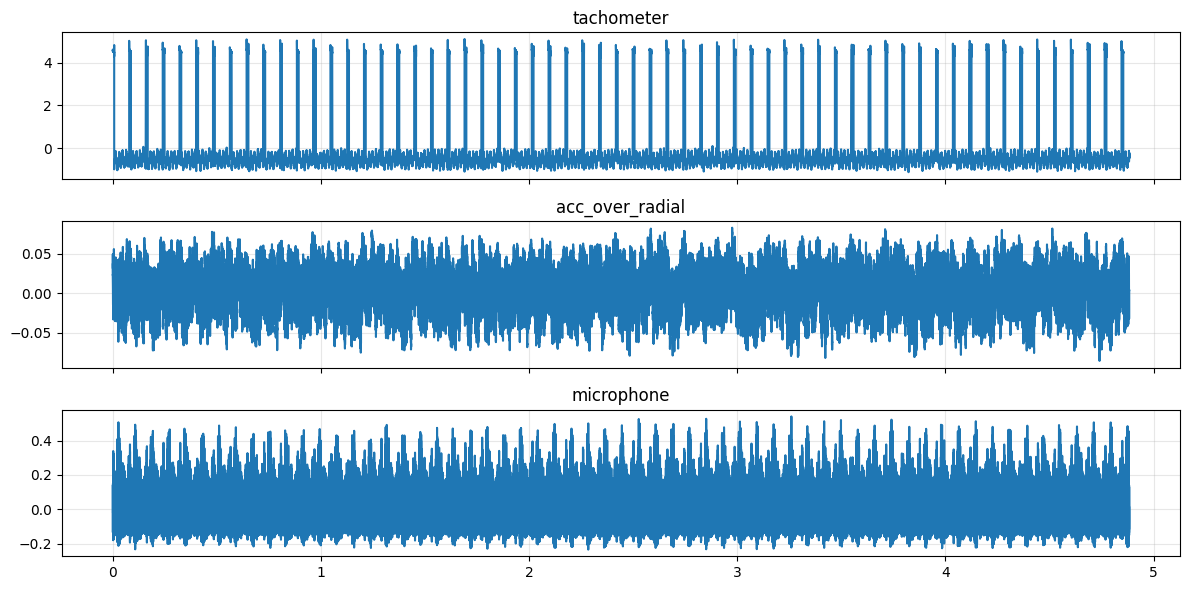

In [6]:
example = all_csv[0]
df = pd.read_csv(example, header=None, names=sensor_names)
t = np.arange(len(df)) / FS

rpm_nom = rpm_from_filename(example)
fault_type, severity, position = parse_labels(example, root)

print("Archivo:", example)
print("RPM nominal:", rpm_nom)
print("Clase:", fault_type, "| severidad:", severity, "| posición:", position)

fig, ax = plt.subplots(3, 1, figsize=(12, 6), sharex=True)
ax[0].plot(t, df["tachometer"]); ax[0].set_title("tachometer")
ax[1].plot(t, df["acc_over_radial"]); ax[1].set_title("acc_over_radial")
ax[2].plot(t, df["microphone"]); ax[2].set_title("microphone")
for a in ax: a.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Features

In [7]:
def time_feats(x):
    x = np.asarray(x)
    rms = np.sqrt(np.mean(x**2))
    return {
        "rms": rms,
        "std": np.std(x),
        "mean": np.mean(x),
        "kurtosis": kurtosis(x, fisher=False),
        "skew": skew(x),
        "crest_factor": np.max(np.abs(x)) / (rms + 1e-12),
        "ptp": np.ptp(x),
    }

def total_vibration(df, prefix):
    a = df[f"{prefix}_axial"].values
    r = df[f"{prefix}_radial"].values
    tg = df[f"{prefix}_tangential"].values
    return np.sqrt(a*a + r*r + tg*tg)

def bandpass(x, fs, low, high, order=4):
    b, a = butter(order, [low/(fs/2), high/(fs/2)], btype="band")
    return filtfilt(b, a, x)

def band_energy(freqs, psd, f0, tol=0.1):
    mask = (freqs >= f0*(1-tol)) & (freqs <= f0*(1+tol))
    return np.trapezoid(psd[mask], freqs[mask]) if np.any(mask) else 0.0

def order_features(x, fs, fr_hz):
    """
    Features de energía alrededor de órdenes 1x..5x (frecuencia = orden * fr).
    """
    freqs, psd = welch(x - np.mean(x), fs=fs, nperseg=8192)
    out = {}
    for o in [1, 2, 3, 4, 5]:
        out[f"ord_{o}x"] = band_energy(freqs, psd, f0=o*fr_hz, tol=0.05)
    out["psd_total"] = np.trapezoid(psd, freqs)
    return out

def envelope_features(x, fs, fr_hz):
    """
    Envolvente para impactos típicos de rodamientos.
    Se filtra (500–8000 Hz), Hilbert, PSD de la envolvente y energía en bandas objetivo.
    Targets aproximados por órdenes:
      FTF~0.375x, BSF~1.87x, BPFO~3x, BPFI~5x
    """
    xf = bandpass(x - np.mean(x), fs, low=500, high=8000)
    env = np.abs(hilbert(xf))
    freqs, psd = welch(env, fs=fs, nperseg=8192)

    targets = {
        "env_FTF": 0.375 * fr_hz,
        "env_BSF": 1.87  * fr_hz,
        "env_BPFO": 3.0  * fr_hz,
        "env_BPFI": 5.0  * fr_hz,
    }
    out = {k: band_energy(freqs, psd, v, tol=0.1) for k, v in targets.items()}
    out["env_total"] = np.trapezoid(psd, freqs)
    return out

In [8]:
def extract_features_from_file(p: Path):
    df = pd.read_csv(p, header=None, names=sensor_names)

    rpm = rpm_from_filename(p)
    fr = rpm / 60.0

    feats = {
        "series_id": str(p.relative_to(root)),
        "rpm": rpm
    }

    # Vibración total bajo/sobre voladizo
    under_total = total_vibration(df, "acc_under")
    over_total  = total_vibration(df, "acc_over")

    feats.update({f"under_total_{k}": v for k, v in time_feats(under_total).items()})
    feats.update({f"over_total_{k}": v for k, v in time_feats(over_total).items()})

    # Acelerómetros clave (radial suele ser muy informativo)
    for s in ["acc_over_radial", "acc_under_radial"]:
        x = df[s].values
        feats.update({f"{s}_{k}": v for k, v in time_feats(x).items()})
        feats.update({f"{s}_{k}": v for k, v in order_features(x, FS, fr).items()})
        feats.update({f"{s}_{k}": v for k, v in envelope_features(x, FS, fr).items()})

    # Tacómetro como canal adicional (no para rpm): solo temporales + PSD total
    xt = df["tachometer"].values
    feats.update({f"tacho_{k}": v for k, v in time_feats(xt).items()})
    feats.update({f"tacho_{k}": v for k, v in order_features(xt, FS, fr).items()})

    # Micrófono como apoyo
    xm = df["microphone"].values
    feats.update({f"micro_{k}": v for k, v in time_feats(xm).items()})
    feats.update({f"micro_{k}": v for k, v in order_features(xm, FS, fr).items()})

    return feats

# Dataset:

In [9]:
rows = []
for p in all_csv:
    fault_type, severity, position = parse_labels(p, root)
    feats = extract_features_from_file(p)
    feats["fault_type"] = fault_type
    feats["severity"] = severity
    feats["position"] = position
    rows.append(feats)

data = pd.DataFrame(rows)
print("Shape:", data.shape)
data.head()

Shape: (168, 81)


,series_id,rpm,under_total_rms,under_total_std,under_total_mean,under_total_kurtosis,under_total_skew,under_total_crest_factor,under_total_ptp,over_total_rms,...,micro_ptp,micro_ord_1x,micro_ord_2x,micro_ord_3x,micro_ord_4x,micro_ord_5x,micro_psd_total,fault_type,severity,position
0,normal\12.288.csv,737.280,1.027265,0.468286,0.914320,2.917963,0.321824,3.105288,3.182210,0.698060,...,0.77416,0.0,0.000000,0.000000,0.000000,0.000000,0.012068,normal,None,None
1,normal\30.72.csv,1843.200,0.976108,0.438113,0.872263,4.461860,0.860205,3.744708,3.649106,0.752001,...,1.10523,0.0,0.000000,0.000000,0.000081,0.000009,0.027461,normal,None,None
2,normal\49.5616.csv,2973.696,0.826850,0.359481,0.744617,4.316087,0.896952,4.029764,3.321177,0.552978,...,1.93630,0.0,0.000000,0.000134,0.000035,0.000048,0.037905,normal,None,None
3,normal\61.44.csv,3686.400,0.858057,0.365374,0.776378,3.871207,0.787140,3.461140,2.959499,0.627821,...,1.32286,0.0,0.000059,0.000141,0.000090,0.000031,0.046548,normal,None,None
4,vertical-misalignment\0.51mm\12.4928.csv,749.568,1.474840,0.787673,1.246885,5.130835,1.165138,4.240037,6.248382,2.857129,...,1.23658,0.0,0.000000,0.000000,0.000000,0.000000,0.018907,vertical-misalignment,0.51mm,None


# Baseline

In [10]:
# Quitamos columnas no numéricas que no queremos como features
X = data.drop(columns=["series_id", "fault_type", "severity", "position"])
y = data["fault_type"]

# Split estratificado por clase
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (134, 77) Test: (34, 77)


In [11]:
clf = RandomForestClassifier(
    n_estimators=500,
    random_state=RANDOM_STATE,
    class_weight="balanced",
    n_jobs=-1
)

clf.fit(X_train, y_train)
pred = clf.predict(X_test)

print(classification_report(y_test, pred, zero_division=0))

                         precision    recall  f1-score   support

             ball_fault       1.00      1.00      1.00         6
             cage_fault       0.50      0.33      0.40         6
horizontal-misalignment       0.33      0.33      0.33         3
              imbalance       1.00      0.67      0.80         6
                 normal       0.00      0.00      0.00         1
             outer_race       0.67      0.86      0.75         7
  vertical-misalignment       0.38      0.60      0.46         5

               accuracy                           0.65        34
              macro avg       0.55      0.54      0.53        34
           weighted avg       0.66      0.65      0.64        34



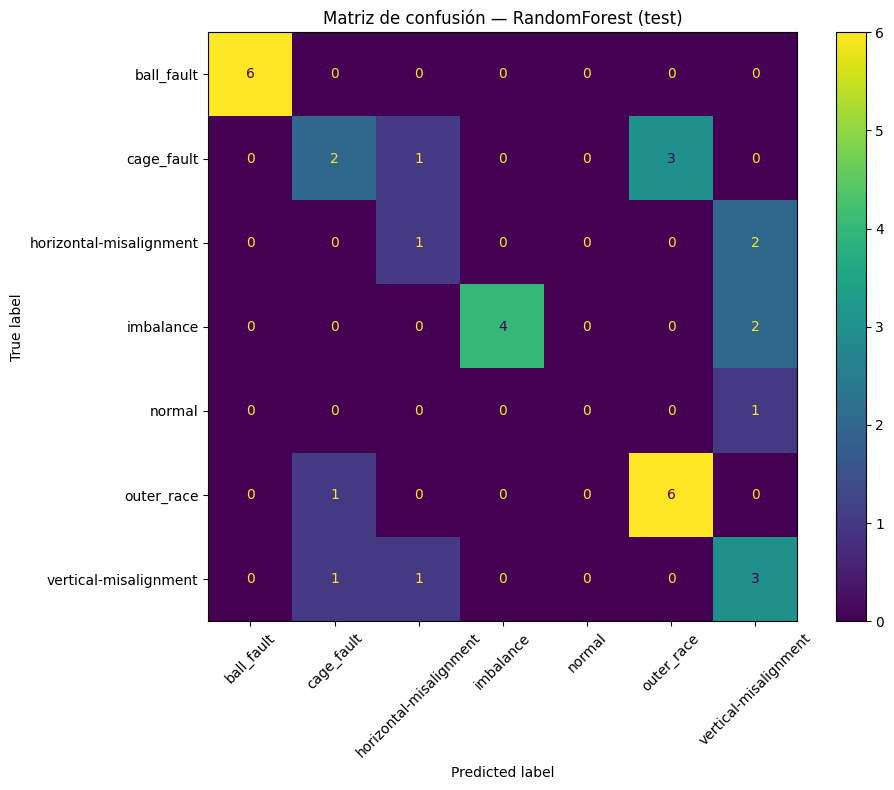

In [12]:
labels = sorted(y.unique())
cm = confusion_matrix(y_test, pred, labels=labels)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)

fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(ax=ax, xticks_rotation=45, values_format="d")
ax.set_title("Matriz de confusión — RandomForest (test)")
plt.tight_layout()
plt.show()

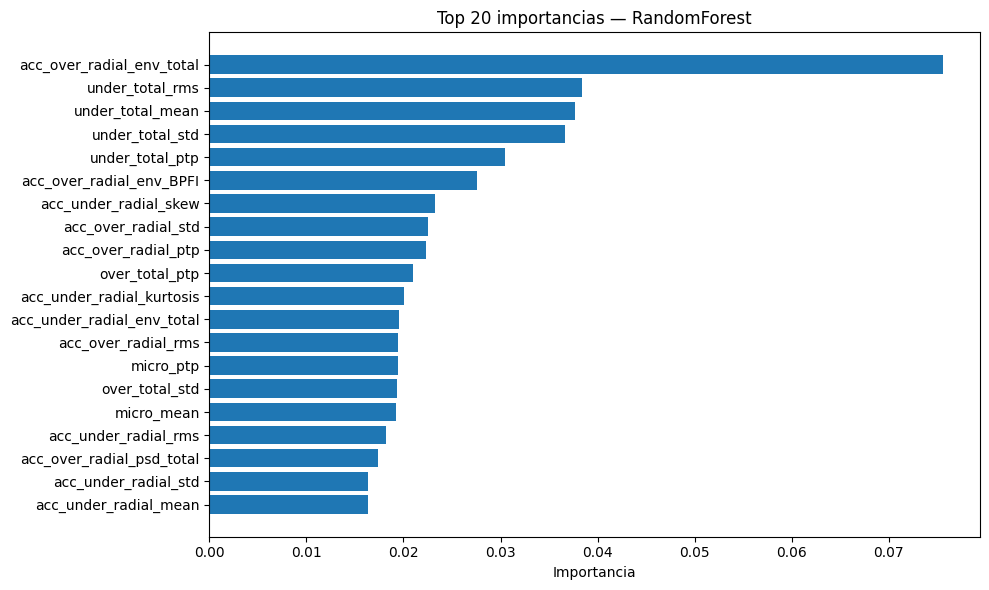

In [13]:
importances = pd.Series(clf.feature_importances_, index=X.columns).sort_values(ascending=False)
top20 = importances.head(20)

plt.figure(figsize=(10,6))
plt.barh(top20.index[::-1], top20.values[::-1])
plt.title("Top 20 importancias — RandomForest")
plt.xlabel("Importancia")
plt.tight_layout()
plt.show()

In [14]:
# Seleccionando features:
top20 = importances.head(20)

In [15]:
top_features = top20.index.tolist()

X_train_sel = X_train[top_features]
X_test_sel  = X_test[top_features]


In [16]:
rf_sel = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf_sel.fit(X_train_sel, y_train)
pred_rf_sel = rf_sel.predict(X_test_sel)

print(classification_report(y_test, pred_rf_sel, zero_division=0))

                         precision    recall  f1-score   support

             ball_fault       0.86      1.00      0.92         6
             cage_fault       0.67      0.33      0.44         6
horizontal-misalignment       0.33      0.33      0.33         3
              imbalance       1.00      0.67      0.80         6
                 normal       0.00      0.00      0.00         1
             outer_race       0.78      1.00      0.88         7
  vertical-misalignment       0.38      0.60      0.46         5

               accuracy                           0.68        34
              macro avg       0.57      0.56      0.55        34
           weighted avg       0.69      0.68      0.66        34



# Algoritmo 2

In [17]:
from sklearn.ensemble import HistGradientBoostingClassifier

gb = HistGradientBoostingClassifier(
    max_depth=6,
    learning_rate=0.1,
    max_iter=300,
    random_state=42
)
gb.fit(X_train, y_train)
pred_gb = gb.predict(X_test)
print(classification_report(y_test, pred_gb, zero_division=0))

                         precision    recall  f1-score   support

             ball_fault       0.67      1.00      0.80         6
             cage_fault       0.60      0.50      0.55         6
horizontal-misalignment       0.50      0.33      0.40         3
              imbalance       0.86      1.00      0.92         6
                 normal       0.00      0.00      0.00         1
             outer_race       0.83      0.71      0.77         7
  vertical-misalignment       0.60      0.60      0.60         5

               accuracy                           0.71        34
              macro avg       0.58      0.59      0.58        34
           weighted avg       0.68      0.71      0.68        34



In [18]:
gb_sel = HistGradientBoostingClassifier(
    max_depth=6,
    learning_rate=0.1,
    max_iter=300,
    random_state=42
)

gb_sel.fit(X_train_sel, y_train)
pred_gb_sel = gb_sel.predict(X_test_sel)

print(classification_report(y_test, pred_gb_sel, zero_division=0))

                         precision    recall  f1-score   support

             ball_fault       0.75      1.00      0.86         6
             cage_fault       0.75      0.50      0.60         6
horizontal-misalignment       0.33      0.33      0.33         3
              imbalance       0.86      1.00      0.92         6
                 normal       0.50      1.00      0.67         1
             outer_race       0.83      0.71      0.77         7
  vertical-misalignment       0.75      0.60      0.67         5

               accuracy                           0.74        34
              macro avg       0.68      0.74      0.69        34
           weighted avg       0.74      0.74      0.73        34



# Algoritmo 3

In [19]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

svm = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", class_weight="balanced"))
])

svm.fit(X_train, y_train)
pred_svm = svm.predict(X_test)
print(classification_report(y_test, pred_svm, zero_division=0))

                         precision    recall  f1-score   support

             ball_fault       0.50      1.00      0.67         6
             cage_fault       1.00      0.17      0.29         6
horizontal-misalignment       0.00      0.00      0.00         3
              imbalance       1.00      0.33      0.50         6
                 normal       0.00      0.00      0.00         1
             outer_race       0.75      0.43      0.55         7
  vertical-misalignment       0.50      0.40      0.44         5

               accuracy                           0.41        34
              macro avg       0.54      0.33      0.35        34
           weighted avg       0.67      0.41      0.43        34



In [20]:
svm_sel = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", class_weight="balanced"))
])

svm_sel.fit(X_train_sel, y_train)
pred_svm_sel = svm_sel.predict(X_test_sel)

print(classification_report(y_test, pred_svm_sel, zero_division=0))

                         precision    recall  f1-score   support

             ball_fault       0.75      1.00      0.86         6
             cage_fault       1.00      0.17      0.29         6
horizontal-misalignment       0.00      0.00      0.00         3
              imbalance       0.75      0.50      0.60         6
                 normal       0.09      1.00      0.17         1
             outer_race       0.75      0.86      0.80         7
  vertical-misalignment       1.00      0.20      0.33         5

               accuracy                           0.53        34
              macro avg       0.62      0.53      0.43        34
           weighted avg       0.75      0.53      0.53        34



# Algoritmo 4

In [21]:
from sklearn.linear_model import LogisticRegression

logreg = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(max_iter=500, class_weight="balanced"))
])

logreg.fit(X_train, y_train)
pred_lr = logreg.predict(X_test)
print(classification_report(y_test, pred_lr, zero_division=0))

                         precision    recall  f1-score   support

             ball_fault       0.75      1.00      0.86         6
             cage_fault       0.75      0.50      0.60         6
horizontal-misalignment       0.25      0.33      0.29         3
              imbalance       1.00      0.83      0.91         6
                 normal       0.00      0.00      0.00         1
             outer_race       0.71      0.71      0.71         7
  vertical-misalignment       0.50      0.40      0.44         5

               accuracy                           0.65        34
              macro avg       0.57      0.54      0.54        34
           weighted avg       0.68      0.65      0.66        34



# Comparación

In [22]:
results = {
    "RandomForest": clf,
    "GradientBoosting": gb,
    "SVM": svm,
    "LogisticRegression": logreg
}

from sklearn.metrics import f1_score

summary = []

for name, model in results.items():
    pred = model.predict(X_test)
    summary.append({
        "model": name,
        "f1_macro": f1_score(y_test, pred, average="macro"),
        "f1_weighted": f1_score(y_test, pred, average="weighted")
    })

pd.DataFrame(summary)

,model,f1_macro,f1_weighted
0,RandomForest,0.534982,0.639932
1,GradientBoosting,0.576823,0.682230
2,SVM,0.348897,0.433961
3,LogisticRegression,0.544383,0.655199


In [23]:
summary = pd.DataFrame([
    {
        "Model": "RF (all features)",
        "F1_macro": f1_score(y_test, pred, average="macro"),
        "F1_weighted": f1_score(y_test, pred, average="weighted")
    },
    {
        "Model": "RF (top 20)",
        "F1_macro": f1_score(y_test, pred_rf_sel, average="macro"),
        "F1_weighted": f1_score(y_test, pred_rf_sel, average="weighted")
    },
    {
        "Model": "GB (top 20)",
        "F1_macro": f1_score(y_test, pred_gb_sel, average="macro"),
        "F1_weighted": f1_score(y_test, pred_gb_sel, average="weighted")
    },
    {
        "Model": "SVM (top 20)",
        "F1_macro": f1_score(y_test, pred_svm_sel, average="macro"),
        "F1_weighted": f1_score(y_test, pred_svm_sel, average="weighted")
    }
])

summary

,Model,F1_macro,F1_weighted
0,RF (all features),0.544383,0.655199
1,RF (top 20),0.548199,0.659936
2,GB (top 20),0.688017,0.725469
3,SVM (top 20),0.434694,0.526190


# Dataset completo + ventanas

In [24]:
root = Path.cwd() / "bearing_fault_detection"

all_csv = list(root.rglob("*.csv"))
print("Nº de CSV encontrados:", len(all_csv))
print("Ejemplo:", all_csv[0] if all_csv else "No hay CSV")

Nº de CSV encontrados: 1951
Ejemplo: C:\Users\amo12\Documents\GitHub\grupo1reto2\Rodamientos\bearing_fault_detection\normal\12.288.csv


In [25]:
def parse_labels(p: Path, root: Path):
    """
    Soporta:
      normal/<rpm>.csv
      imbalance/<6g|10g|...>/<rpm>.csv
      horizontal-misalignment/<0.5mm|...>/<rpm>.csv
      vertical-misalignment/<...>/<rpm>.csv
      overhang/<ball_fault|cage_fault|outer_race|inner_race>/<0g|6g|10g|20g>/<rpm>.csv
      underhang/<...>/<...>/<rpm>.csv
    """
    rel = p.relative_to(root)
    parts = rel.parts

    top = parts[0]  # normal, imbalance, horizontal-misalignment, vertical-misalignment, overhang, underhang

    fault_type = top
    severity = None
    position = None

    if top in ["imbalance", "horizontal-misalignment", "vertical-misalignment"]:
        severity = parts[1]  # 6g, 0.5mm, 0.51mm, etc.

    if top in ["overhang", "underhang"]:
        position = top
        fault_type = parts[1]  # ball_fault / cage_fault / outer_race / inner_race
        severity = parts[2]    # 0g / 6g / 10g / 20g

    return fault_type, severity, position

## Guardamos parte para ingesta

In [27]:
from collections import defaultdict
import numpy as np
import pandas as pd

def guaranteed_split(files, root, train_ratio=0.7, val_ratio=0.15, test_ratio=0.15, seed=42):
    rng = np.random.default_rng(seed)

    by_class = defaultdict(list)
    for p in files:
        c = parse_labels(p, root)[0]
        by_class[c].append(p)

    train_files, val_files, test_files = [], [], []
    report = []

    for c, lst in by_class.items():
        lst = lst.copy()
        rng.shuffle(lst)
        n = len(lst)

        # Si una clase tiene muy pocos archivos, no se puede meter en los 3 splits.
        if n < 3:
            # Estrategia: 1 en test, 1 en val si se puede, resto en train.
            if n == 1:
                train_files += lst
                report.append((c, n, "solo_train"))
            elif n == 2:
                train_files.append(lst[0])
                test_files.append(lst[1])
                report.append((c, n, "train+test (sin val)"))
            continue

        # mínimo 1 en val y 1 en test
        n_test = max(1, int(round(n * test_ratio)))
        n_val  = max(1, int(round(n * val_ratio)))
        if n_test + n_val >= n:
            n_test = 1
            n_val = 1

        test_c = lst[:n_test]
        val_c  = lst[n_test:n_test+n_val]
        train_c = lst[n_test+n_val:]

        train_files += train_c
        val_files   += val_c
        test_files  += test_c

        report.append((c, n, f"train={len(train_c)}, val={len(val_c)}, test={len(test_c)}"))

    report_df = pd.DataFrame(report, columns=["class","n_files","split_info"]).sort_values("class")
    return train_files, val_files, test_files, report_df

train_files, val_files, test_files, report_df = guaranteed_split(all_csv, root)

print("train/val/test:", len(train_files), len(val_files), len(test_files))
report_df


CSV de etiquetas de test generado en test_labels.csv, total filas: 292
train/val/test: 1367 292 292


,class,n_files,split_info
4,ball_fault,323,"train=227, val=48, test=48"
3,cage_fault,376,"train=264, val=56, test=56"
6,horizontal-misalignment,197,"train=137, val=30, test=30"
5,imbalance,333,"train=233, val=50, test=50"
0,normal,49,"train=35, val=7, test=7"
2,outer_race,372,"train=260, val=56, test=56"
1,vertical-misalignment,301,"train=211, val=45, test=45"


In [29]:
import csv

# CSV de salida
test_labels_file = Path("test_labels.csv")

# Tipos de fallo válidos
fault_types = [
    "normal",
    "horizontal-misalignment",
    "vertical-misalignment",
    "imbalance",
    "ball_fault",
    "cage_fault",
    "outer_race"
]

rows = []
for csv_path in test_files:  # Solo los archivos de test
    frequency = csv_path.stem
    fault_type = None
    for ft in fault_types:
        if ft in str(csv_path):  # Buscar en toda la ruta
            fault_type = ft
            break
    if fault_type is None:
        raise ValueError(f"No se pudo determinar fault_type para {csv_path}")
    rows.append({"frequency": frequency, "fault_type": fault_type})

# Ordenar por frequency numéricamente
rows.sort(key=lambda x: float(x["frequency"]))

# Escribir CSV
with open(test_labels_file, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=["frequency", "fault_type"])
    writer.writeheader()
    writer.writerows(rows)

print(f"CSV de etiquetas de test generado en {test_labels_file}, total filas: {len(rows)}")

CSV de etiquetas de test generado en test_labels.csv, total filas: 292


In [26]:
def class_counts(file_list):
    return pd.Series([parse_labels(p, root)[0] for p in file_list]).value_counts()

print("TRAIN:\n", class_counts(train_files), "\n")
print("VAL:\n", class_counts(val_files), "\n")
print("TEST:\n", class_counts(test_files), "\n")

TRAIN:
 cage_fault                 264
outer_race                 260
imbalance                  233
ball_fault                 227
vertical-misalignment      211
horizontal-misalignment    137
normal                      35
Name: count, dtype: int64 

VAL:
 outer_race                 56
cage_fault                 56
imbalance                  50
ball_fault                 48
vertical-misalignment      45
horizontal-misalignment    30
normal                      7
Name: count, dtype: int64 

TEST:
 outer_race                 56
cage_fault                 56
imbalance                  50
ball_fault                 48
vertical-misalignment      45
horizontal-misalignment    30
normal                      7
Name: count, dtype: int64 



In [54]:
import shutil

# Carpeta destino
production_dir = Path("production")
production_dir.mkdir(exist_ok=True)  # crea la carpeta si no existe

for file_path in test_files:
    src = Path(file_path)        # origen
    dst = production_dir / src.name  # destino con mismo nombre de archivo
    shutil.copy(src, dst)

In [27]:
FS = 51200

window_sec = 0.2
window_size = int(window_sec * FS)      # 10240
step = window_size // 2                 # 5120 (50% solape)

def iter_windows(x, window_size, step):
    for start in range(0, len(x) - window_size + 1, step):
        yield x[start:start + window_size], start

window_size, step

(10240, 5120)

“Aunque el uso de ventanas sincronizadas con un número entero de ciclos puede resultar beneficioso para el análisis espectral clásico, en este trabajo se emplean ventanas temporales de duración fija. Este enfoque permite una detección temprana y homogénea independientemente de la velocidad de rotación, y resulta adecuado para la extracción de características estadísticas y de envolvente utilizadas por los modelos de aprendizaje automático.”

## Features por ventana

In [28]:
def extract_window_features_from_file(p: Path, window_size, step):
    df = pd.read_csv(p, header=None, names=sensor_names)

    rpm = rpm_from_filename(p)
    fr = rpm / 60.0

    fault_type, severity, position = parse_labels(p, root)

    sig_over = df["acc_over_radial"].values
    sig_under = df["acc_under_radial"].values

    rows = []
    win_id = 0

    for w_over, start in iter_windows(sig_over, window_size, step):
        w_under = sig_under[start:start+window_size]

        row = {
            "series_id": str(p.relative_to(root)),
            "window_id": win_id,
            "t_start_s": start / FS,
            "rpm": rpm,
            "fault_type": fault_type,
        }

        # Over radial
        row.update({f"acc_over_radial_{k}": v for k,v in time_feats(w_over).items()})
        row.update({f"acc_over_radial_{k}": v for k,v in order_features(w_over, FS, fr).items()})
        row.update({f"acc_over_radial_{k}": v for k,v in envelope_features(w_over, FS, fr).items()})

        # Under radial
        row.update({f"acc_under_radial_{k}": v for k,v in time_feats(w_under).items()})
        row.update({f"acc_under_radial_{k}": v for k,v in order_features(w_under, FS, fr).items()})
        row.update({f"acc_under_radial_{k}": v for k,v in envelope_features(w_under, FS, fr).items()})

        rows.append(row)
        win_id += 1

    return rows

In [29]:
def build_window_dataset(file_list, window_size, step):
    rows = []
    for p in file_list:
        rows.extend(extract_window_features_from_file(p, window_size, step))
    return pd.DataFrame(rows)

train_win = build_window_dataset(train_files, window_size, step)
val_win   = build_window_dataset(val_files, window_size, step)
test_win  = build_window_dataset(test_files, window_size, step)

print(train_win.shape, val_win.shape, test_win.shape)
train_win.head()

(64249, 41) (13724, 41) (13724, 41)


,series_id,window_id,t_start_s,rpm,fault_type,acc_over_radial_rms,acc_over_radial_std,acc_over_radial_mean,acc_over_radial_kurtosis,acc_over_radial_skew,...,acc_under_radial_ord_2x,acc_under_radial_ord_3x,acc_under_radial_ord_4x,acc_under_radial_ord_5x,acc_under_radial_psd_total,acc_under_radial_env_FTF,acc_under_radial_env_BSF,acc_under_radial_env_BPFO,acc_under_radial_env_BPFI,acc_under_radial_env_total
0,normal\16.1792.csv,0,0.0,970.752,normal,0.029572,0.029488,0.002226,2.205796,-0.150032,...,0.0,0.0,0.0,0.0,0.109195,0.0,0.0,0.000019,0.000025,0.002465
1,normal\16.1792.csv,1,0.1,970.752,normal,0.028356,0.028285,-0.002007,2.007910,-0.113927,...,0.0,0.0,0.0,0.0,0.095438,0.0,0.0,0.000003,0.000003,0.002104
2,normal\16.1792.csv,2,0.2,970.752,normal,0.028419,0.028400,0.001051,2.082252,-0.003545,...,0.0,0.0,0.0,0.0,0.104640,0.0,0.0,0.000008,0.000010,0.001907
3,normal\16.1792.csv,3,0.3,970.752,normal,0.028676,0.028636,0.001523,2.186776,-0.104132,...,0.0,0.0,0.0,0.0,0.101660,0.0,0.0,0.000004,0.000043,0.002355
4,normal\16.1792.csv,4,0.4,970.752,normal,0.029107,0.029107,0.000111,2.129206,-0.083262,...,0.0,0.0,0.0,0.0,0.100647,0.0,0.0,0.000007,0.000020,0.001795


In [30]:
train_win

,series_id,window_id,t_start_s,rpm,fault_type,acc_over_radial_rms,acc_over_radial_std,acc_over_radial_mean,acc_over_radial_kurtosis,acc_over_radial_skew,...,acc_under_radial_ord_2x,acc_under_radial_ord_3x,acc_under_radial_ord_4x,acc_under_radial_ord_5x,acc_under_radial_psd_total,acc_under_radial_env_FTF,acc_under_radial_env_BSF,acc_under_radial_env_BPFO,acc_under_radial_env_BPFI,acc_under_radial_env_total
0,normal\16.1792.csv,0,0.0,970.752,normal,0.029572,0.029488,0.002226,2.205796,-0.150032,...,0.0,0.000000,0.000000,0.000000,0.109195,0.0,0.000000,0.000019,0.000025,0.002465
1,normal\16.1792.csv,1,0.1,970.752,normal,0.028356,0.028285,-0.002007,2.007910,-0.113927,...,0.0,0.000000,0.000000,0.000000,0.095438,0.0,0.000000,0.000003,0.000003,0.002104
2,normal\16.1792.csv,2,0.2,970.752,normal,0.028419,0.028400,0.001051,2.082252,-0.003545,...,0.0,0.000000,0.000000,0.000000,0.104640,0.0,0.000000,0.000008,0.000010,0.001907
3,normal\16.1792.csv,3,0.3,970.752,normal,0.028676,0.028636,0.001523,2.186776,-0.104132,...,0.0,0.000000,0.000000,0.000000,0.101660,0.0,0.000000,0.000004,0.000043,0.002355
4,normal\16.1792.csv,4,0.4,970.752,normal,0.029107,0.029107,0.000111,2.129206,-0.083262,...,0.0,0.000000,0.000000,0.000000,0.100647,0.0,0.000000,0.000007,0.000020,0.001795
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64244,horizontal-misalignment\1.0mm\37.0688.csv,42,4.2,2224.128,horizontal-misalignment,0.036634,0.036382,-0.004286,2.843106,-0.144571,...,0.0,0.001293,0.000274,0.000293,0.158832,0.0,0.000695,0.000424,0.000035,0.018745
64245,horizontal-misalignment\1.0mm\37.0688.csv,43,4.3,2224.128,horizontal-misalignment,0.038734,0.036833,0.011988,2.618389,-0.195100,...,0.0,0.001078,0.000016,0.001064,0.192559,0.0,0.001334,0.000369,0.000310,0.025616
64246,horizontal-misalignment\1.0mm\37.0688.csv,44,4.4,2224.128,horizontal-misalignment,0.042755,0.041215,0.011371,3.140050,-0.503711,...,0.0,0.000532,0.000224,0.000188,0.162136,0.0,0.000128,0.000608,0.000094,0.023131
64247,horizontal-misalignment\1.0mm\37.0688.csv,45,4.5,2224.128,horizontal-misalignment,0.040853,0.040301,0.006691,3.324589,-0.542402,...,0.0,0.001263,0.000031,0.000449,0.197061,0.0,0.000425,0.000186,0.000821,0.024258


## Modelos

                         precision    recall  f1-score   support

             ball_fault       1.00      1.00      1.00      2256
             cage_fault       0.90      0.98      0.94      2632
horizontal-misalignment       0.96      0.98      0.97      1410
              imbalance       0.98      0.93      0.95      2350
                 normal       0.96      0.79      0.87       329
             outer_race       0.98      0.96      0.97      2632
  vertical-misalignment       0.98      0.97      0.97      2115

               accuracy                           0.96     13724
              macro avg       0.97      0.94      0.95     13724
           weighted avg       0.97      0.96      0.96     13724



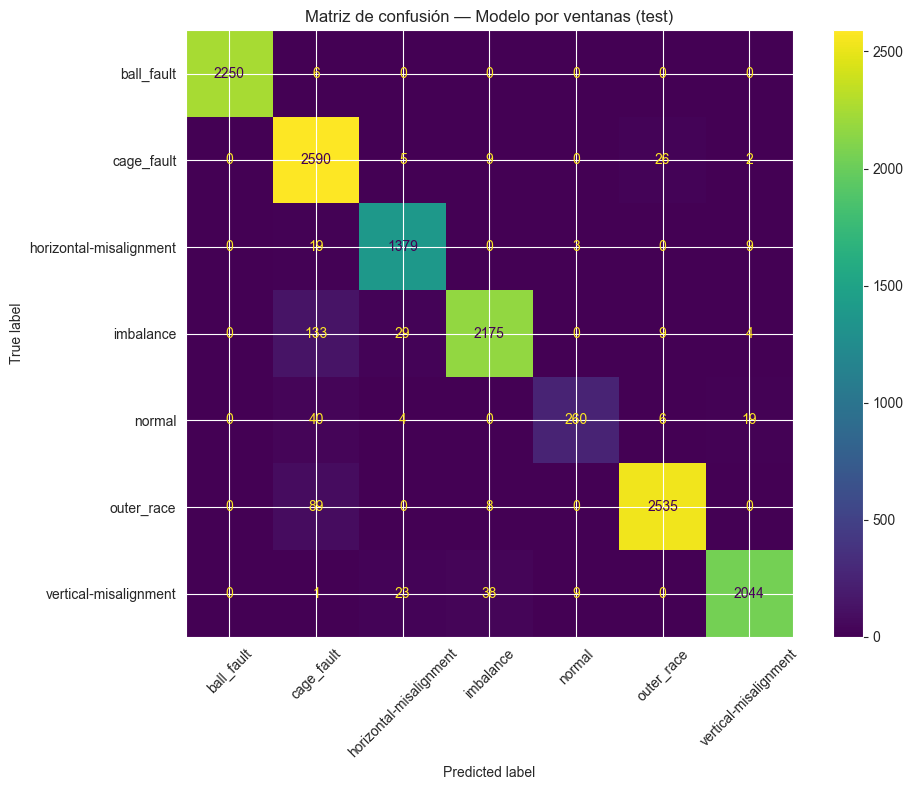

In [32]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier

def prep_xy(df):
    X = df.drop(columns=["series_id","window_id","t_start_s","fault_type"])
    y = df["fault_type"]
    return X, y

Xtr, ytr = prep_xy(train_win)
Xte, yte = prep_xy(test_win)

rf_win = RandomForestClassifier(
    n_estimators=400, random_state=42, class_weight="balanced", n_jobs=-1
)
rf_win.fit(Xtr, ytr)
pred_te = rf_win.predict(Xte)

print(classification_report(yte, pred_te, zero_division=0))

labels = sorted(yte.unique())
cm = confusion_matrix(yte, pred_te, labels=labels)
disp = ConfusionMatrixDisplay(cm, display_labels=labels)

fig, ax = plt.subplots(figsize=(10,8))
disp.plot(ax=ax, xticks_rotation=45, values_format="d")
ax.set_title("Matriz de confusión — Modelo por ventanas (test)")
plt.tight_layout()
plt.show()

## Features clave en ventanas

In [33]:
Xtr = train_win.drop(columns=["series_id","window_id","t_start_s","fault_type"])
ytr = train_win["fault_type"]

rf_base = RandomForestClassifier(
    n_estimators=400,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)
rf_base.fit(Xtr, ytr)

importances = (
    pd.Series(rf_base.feature_importances_, index=Xtr.columns)
    .sort_values(ascending=False)
)

top20 = importances.head(20)
top20


acc_over_radial_env_total        0.133182
acc_under_radial_skew            0.082167
acc_under_radial_env_total       0.067089
acc_under_radial_rms             0.060229
acc_under_radial_std             0.056724
acc_over_radial_ptp              0.051948
rpm                              0.047746
acc_under_radial_kurtosis        0.045937
acc_under_radial_psd_total       0.045171
acc_over_radial_std              0.043116
acc_over_radial_rms              0.042566
acc_under_radial_ptp             0.031858
acc_over_radial_psd_total        0.030503
acc_over_radial_kurtosis         0.023730
acc_under_radial_ord_3x          0.023318
acc_over_radial_env_BPFI         0.022571
acc_under_radial_crest_factor    0.017944
acc_under_radial_ord_5x          0.016768
acc_under_radial_ord_4x          0.016670
acc_over_radial_env_BPFO         0.015762
dtype: float64

In [35]:
# Dataset reducido:
top_features = top20.index.tolist()

Xtr_sel = Xtr[top_features]
Xte_sel = test_win.drop(
    columns=["series_id","window_id","t_start_s","fault_type"]
)[top_features]

yte = test_win["fault_type"]


In [36]:
# Random forest top 20:
rf_sel = RandomForestClassifier(
    n_estimators=400,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)
rf_sel.fit(Xtr_sel, ytr)
pred_rf = rf_sel.predict(Xte_sel)

print("RF top20")
print(classification_report(yte, pred_rf, zero_division=0))


RF top20
                         precision    recall  f1-score   support

             ball_fault       1.00      1.00      1.00      2256
             cage_fault       0.91      0.99      0.95      2632
horizontal-misalignment       0.95      0.98      0.96      1410
              imbalance       0.97      0.92      0.94      2350
                 normal       0.94      0.80      0.86       329
             outer_race       0.99      0.97      0.98      2632
  vertical-misalignment       0.98      0.96      0.97      2115

               accuracy                           0.96     13724
              macro avg       0.96      0.94      0.95     13724
           weighted avg       0.97      0.96      0.96     13724



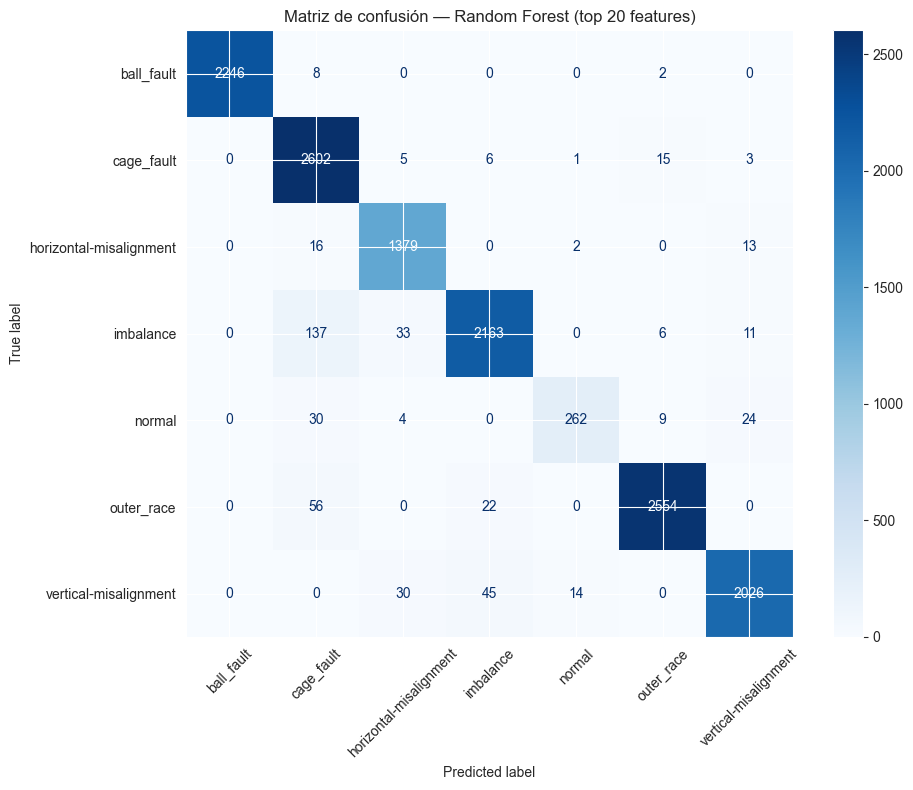

In [37]:
# Matriz de confusión
cm = confusion_matrix(yte, pred_rf, labels=labels)

# Plot
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(
    ax=ax,
    xticks_rotation=45,
    cmap="Blues",
    values_format="d"
)

ax.set_title("Matriz de confusión — Random Forest (top 20 features)")
plt.tight_layout()
plt.show()

In [38]:
# Gradient boosting top 20:
from sklearn.ensemble import HistGradientBoostingClassifier

gb = HistGradientBoostingClassifier(
    max_depth=6,
    learning_rate=0.1,
    max_iter=300,
    random_state=42
)
gb.fit(Xtr_sel, ytr)
pred_gb = gb.predict(Xte_sel)

print("GB top20")
print(classification_report(yte, pred_gb, zero_division=0))


GB top20
                         precision    recall  f1-score   support

             ball_fault       1.00      0.99      1.00      2256
             cage_fault       0.91      0.99      0.95      2632
horizontal-misalignment       0.95      0.96      0.96      1410
              imbalance       0.98      0.93      0.96      2350
                 normal       0.91      0.95      0.93       329
             outer_race       0.99      0.97      0.98      2632
  vertical-misalignment       0.98      0.95      0.97      2115

               accuracy                           0.97     13724
              macro avg       0.96      0.96      0.96     13724
           weighted avg       0.97      0.97      0.97     13724



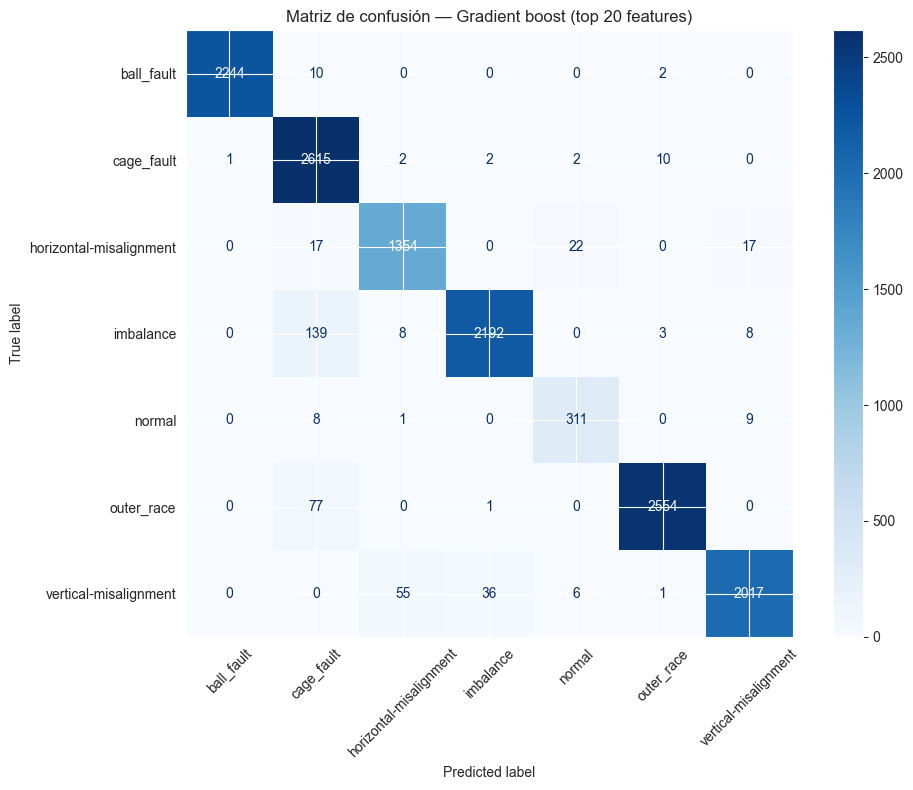

In [39]:
# Matriz de confusión
cm = confusion_matrix(yte, pred_gb, labels=labels)

# Plot
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(
    ax=ax,
    xticks_rotation=45,
    cmap="Blues",
    values_format="d"
)

ax.set_title("Matriz de confusión — Gradient boost (top 20 features)")
plt.tight_layout()
plt.show()

In [40]:
# SVM top 20:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

svm = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", class_weight="balanced"))
])

svm.fit(Xtr_sel, ytr)
pred_svm = svm.predict(Xte_sel)

print("SVM top20")
print(classification_report(yte, pred_svm, zero_division=0))


SVM top20
                         precision    recall  f1-score   support

             ball_fault       0.99      0.99      0.99      2256
             cage_fault       0.84      0.69      0.76      2632
horizontal-misalignment       0.64      0.83      0.72      1410
              imbalance       0.85      0.82      0.83      2350
                 normal       0.39      0.97      0.56       329
             outer_race       0.88      0.86      0.87      2632
  vertical-misalignment       0.82      0.73      0.77      2115

               accuracy                           0.82     13724
              macro avg       0.77      0.84      0.79     13724
           weighted avg       0.84      0.82      0.82     13724



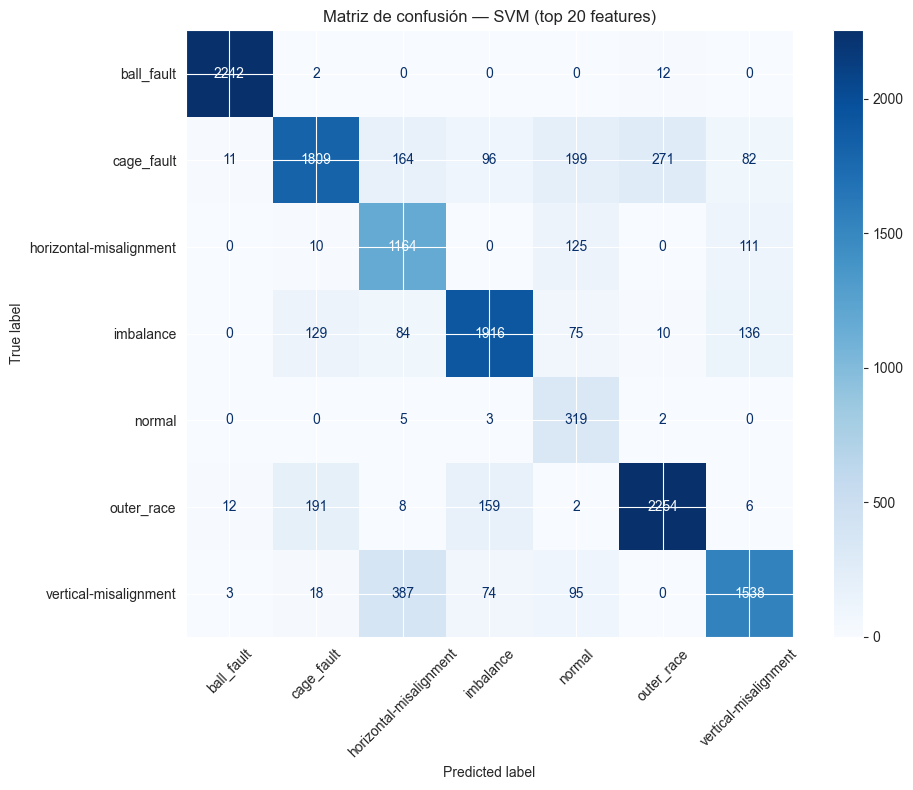

In [41]:
# Matriz de confusión
cm = confusion_matrix(yte, pred_svm, labels=labels)

# Plot
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(
    ax=ax,
    xticks_rotation=45,
    cmap="Blues",
    values_format="d"
)

ax.set_title("Matriz de confusión — SVM (top 20 features)")
plt.tight_layout()
plt.show()

In [42]:
# Logistic regression top 20:
from sklearn.linear_model import LogisticRegression

logreg = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(max_iter=500, class_weight="balanced"))
])

logreg.fit(Xtr_sel, ytr)
pred_lr = logreg.predict(Xte_sel)

print("LogReg top20")
print(classification_report(yte, pred_lr, zero_division=0))


LogReg top20
                         precision    recall  f1-score   support

             ball_fault       0.97      0.99      0.98      2256
             cage_fault       0.59      0.46      0.52      2632
horizontal-misalignment       0.44      0.46      0.45      1410
              imbalance       0.82      0.79      0.81      2350
                 normal       0.12      0.50      0.19       329
             outer_race       0.82      0.67      0.74      2632
  vertical-misalignment       0.64      0.63      0.63      2115

               accuracy                           0.67     13724
              macro avg       0.63      0.64      0.62     13724
           weighted avg       0.72      0.67      0.69     13724



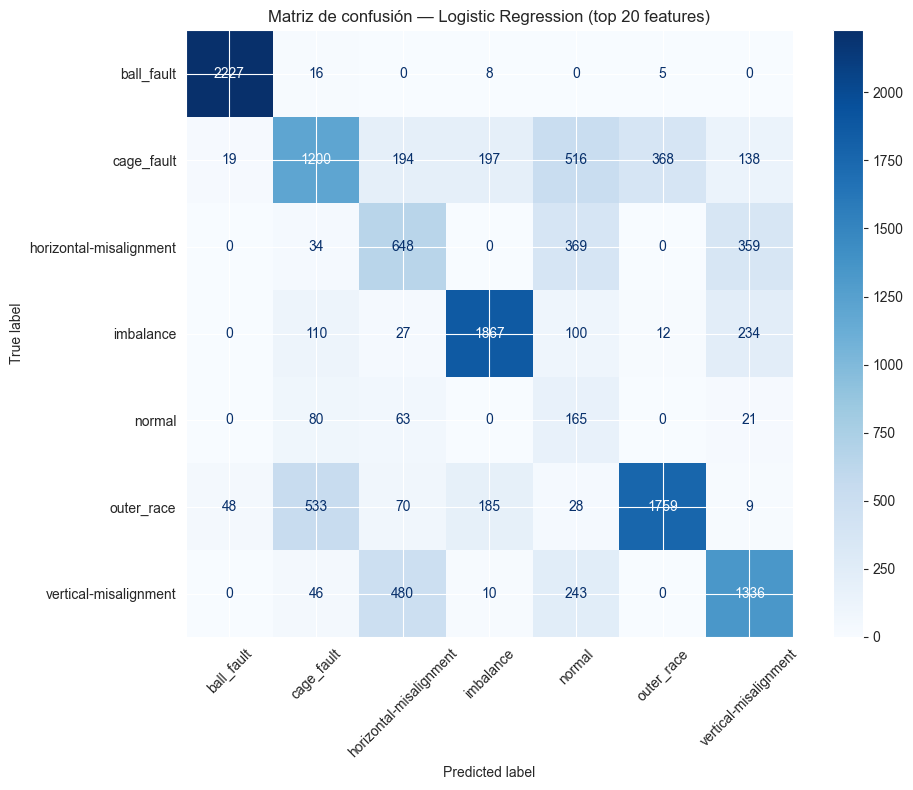

In [43]:
# Matriz de confusión
cm = confusion_matrix(yte, pred_lr, labels=labels)

# Plot
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(
    ax=ax,
    xticks_rotation=45,
    cmap="Blues",
    values_format="d"
)

ax.set_title("Matriz de confusión — Logistic Regression (top 20 features)")
plt.tight_layout()
plt.show()

In [44]:
# Cmparacion:
from sklearn.metrics import f1_score

summary = pd.DataFrame([
    {
        "Model": "RF (top 20)",
        "F1_macro": f1_score(yte, pred_rf, average="macro"),
        "F1_weighted": f1_score(yte, pred_rf, average="weighted")
    },
    {
        "Model": "GB (top 20)",
        "F1_macro": f1_score(yte, pred_gb, average="macro"),
        "F1_weighted": f1_score(yte, pred_gb, average="weighted")
    },
    {
        "Model": "SVM (top 20)",
        "F1_macro": f1_score(yte, pred_svm, average="macro"),
        "F1_weighted": f1_score(yte, pred_svm, average="weighted")
    },
    {
        "Model": "LogReg (top 20)",
        "F1_macro": f1_score(yte, pred_lr, average="macro"),
        "F1_weighted": f1_score(yte, pred_lr, average="weighted")
    },
])

summary


,Model,F1_macro,F1_weighted
0,RF (top 20),0.951701,0.964034
1,GB (top 20),0.962980,0.968318
2,SVM (top 20),0.785910,0.823801
3,LogReg (top 20),0.615907,0.687953


“La Tabla recoge el rendimiento de distintos algoritmos de aprendizaje automático entrenados con las 20 características más relevantes extraídas por ventana. Los modelos basados en ensembles muestran un rendimiento claramente superior, alcanzando valores de F1 superiores a 0.96. En particular, el modelo de Gradient Boosting obtiene el mejor compromiso entre precisión y capacidad de generalización, mientras que el Random Forest presenta un comportamiento muy estable y fácilmente interpretable. Los modelos lineales y SVM presentan un rendimiento inferior, lo que confirma la naturaleza no lineal del problema.”

In [45]:
# Guardar el modelo:
import joblib
joblib.dump(gb, "model_window_gb_top20.pkl")

['model_window_gb_top20.pkl']

## Mejorando el mejor modelo

In [48]:
Xval, yval = prep_xy(val_win)
Xva_sel = Xval[top_features]

In [49]:
param_grid = [
    # Modelos conservadores → alto recall
    {"learning_rate": 0.03, "max_depth": 4, "max_iter": 800, "min_samples_leaf": 30, "l2_regularization": 0.1},
    {"learning_rate": 0.03, "max_depth": 6, "max_iter": 800, "min_samples_leaf": 30, "l2_regularization": 0.1},

    # Compromiso recall / precisión
    {"learning_rate": 0.05, "max_depth": 4, "max_iter": 500, "min_samples_leaf": 20, "l2_regularization": 0.05},
    {"learning_rate": 0.05, "max_depth": 6, "max_iter": 500, "min_samples_leaf": 20, "l2_regularization": 0.05},

    # Más expresivos (por si ayudan en clases complejas)
    {"learning_rate": 0.08, "max_depth": 6, "max_iter": 400, "min_samples_leaf": 20, "l2_regularization": 0.0},
]

In [50]:
from sklearn.metrics import recall_score

best = None
best_score = -1

for i, params in enumerate(param_grid, 1):
    model = HistGradientBoostingClassifier(
        random_state=42,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=20,
        **params
    )

    model.fit(Xtr_sel, ytr)
    pred_val = model.predict(Xva_sel)

    score = recall_score(yval, pred_val, average="macro", zero_division=0)

    print(
        f"[{i}/{len(param_grid)}] "
        f"Recall_macro(val)={score:.4f}  params={params}"
    )

    if score > best_score:
        best_score = score
        best = (model, params)

best_model, best_params = best

print("\n Mejor configuración (optimizada para recall):")
print("Recall_macro(val) =", best_score)
print("params =", best_params)

print("\nReporte en VALIDACIÓN:")
print(classification_report(yval, best_model.predict(Xva_sel), zero_division=0))

[1/5] Recall_macro(val)=0.9307  params={'learning_rate': 0.03, 'max_depth': 4, 'max_iter': 800, 'min_samples_leaf': 30, 'l2_regularization': 0.1}
[2/5] Recall_macro(val)=0.9325  params={'learning_rate': 0.03, 'max_depth': 6, 'max_iter': 800, 'min_samples_leaf': 30, 'l2_regularization': 0.1}
[3/5] Recall_macro(val)=0.9320  params={'learning_rate': 0.05, 'max_depth': 4, 'max_iter': 500, 'min_samples_leaf': 20, 'l2_regularization': 0.05}
[4/5] Recall_macro(val)=0.9318  params={'learning_rate': 0.05, 'max_depth': 6, 'max_iter': 500, 'min_samples_leaf': 20, 'l2_regularization': 0.05}
[5/5] Recall_macro(val)=0.9316  params={'learning_rate': 0.08, 'max_depth': 6, 'max_iter': 400, 'min_samples_leaf': 20, 'l2_regularization': 0.0}

 Mejor configuración (optimizada para recall):
Recall_macro(val) = 0.93246610701018
params = {'learning_rate': 0.03, 'max_depth': 6, 'max_iter': 800, 'min_samples_leaf': 30, 'l2_regularization': 0.1}

Reporte en VALIDACIÓN:
                         precision    recal

In [56]:
Xte_sel

,acc_over_radial_env_total,acc_under_radial_skew,acc_under_radial_env_total,acc_under_radial_rms,acc_under_radial_std,acc_over_radial_ptp,rpm,acc_under_radial_kurtosis,acc_under_radial_psd_total,acc_over_radial_std,acc_over_radial_rms,acc_under_radial_ptp,acc_over_radial_psd_total,acc_over_radial_kurtosis,acc_under_radial_ord_3x,acc_over_radial_env_BPFI,acc_under_radial_crest_factor,acc_under_radial_ord_5x,acc_under_radial_ord_4x,acc_over_radial_env_BPFO
0,0.000099,-0.140223,0.011217,0.374998,0.374994,0.124775,2125.824,2.863833,0.135082,0.028192,0.028193,3.0605,0.000747,1.952775,0.000000,3.394161e-06,4.419756,0.000922,0.000385,1.237509e-06
1,0.000094,-0.145472,0.015655,0.387966,0.387958,0.126874,2125.824,2.929441,0.151275,0.028474,0.028503,3.1074,0.000768,1.977131,0.000000,3.223967e-06,4.272021,0.001723,0.000505,6.058146e-07
2,0.000095,-0.159472,0.010371,0.381649,0.381648,0.126874,2125.824,2.784981,0.149699,0.027816,0.027919,2.9238,0.000844,2.002158,0.000000,1.657663e-06,3.861668,0.001336,0.000389,1.281621e-06
3,0.000094,-0.191114,0.008882,0.364857,0.364848,0.123043,2125.824,2.639318,0.132326,0.027631,0.027819,2.6809,0.000713,1.960671,0.000000,2.857580e-06,3.840961,0.000468,0.000170,2.205625e-06
4,0.000096,-0.265983,0.008545,0.359844,0.359836,0.131822,2125.824,2.690013,0.127347,0.028604,0.028893,2.7399,0.000871,1.995944,0.000000,9.070405e-07,4.207932,0.000516,0.000114,7.689996e-07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13719,0.000099,-0.481633,0.038688,0.511925,0.511925,0.243280,3600.384,3.827794,0.238813,0.041585,0.042521,4.1589,0.001427,2.881959,0.004123,5.735208e-06,4.753040,0.005388,0.008225,3.065321e-06
13720,0.000100,-0.508543,0.045154,0.527855,0.527854,0.237870,3600.384,3.742126,0.255797,0.042053,0.042622,4.1643,0.001567,2.722610,0.002872,4.923441e-06,4.622862,0.006211,0.010271,1.439251e-06
13721,0.000109,-0.529757,0.057483,0.520724,0.520708,0.242350,3600.384,3.743383,0.274719,0.041158,0.041758,4.2322,0.001746,2.747141,0.004770,6.124706e-06,4.686172,0.009694,0.015029,6.912901e-06
13722,0.000096,-0.407055,0.057117,0.497871,0.497839,0.281790,3600.384,3.533526,0.274672,0.041086,0.041675,4.1978,0.001797,3.471568,0.007161,3.706000e-06,4.832171,0.009710,0.004297,1.352777e-06


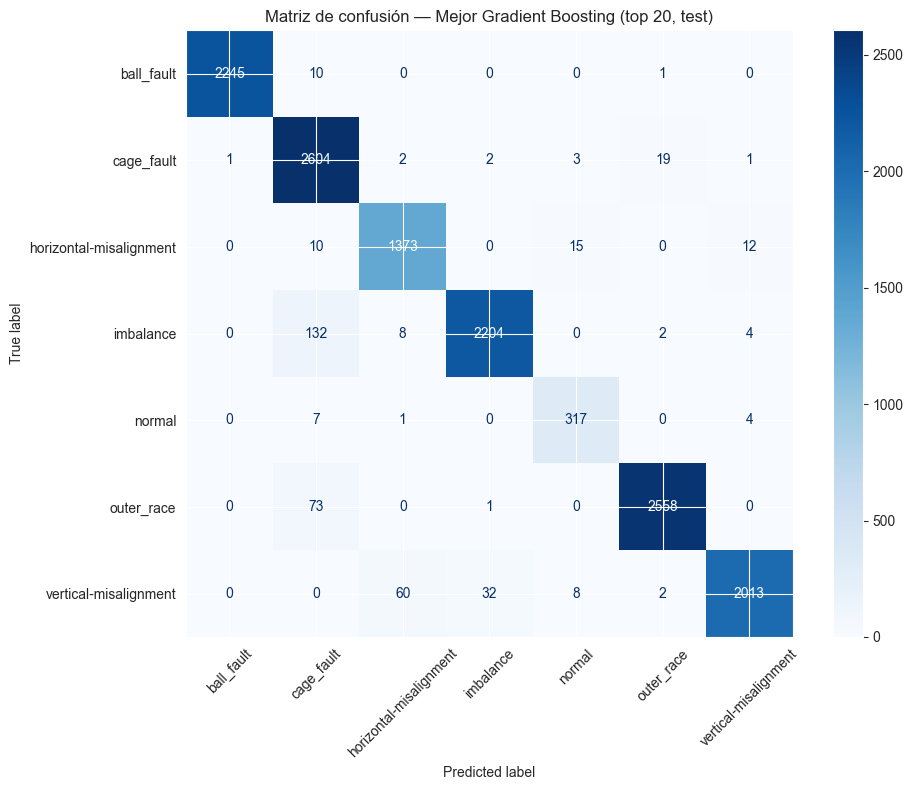

In [51]:
# Predicción en test con el mejor modelo
pred_best = best_model.predict(Xte_sel)

# Etiquetas (ordenadas para consistencia)
labels = np.unique(yte)

# Matriz de confusión
cm = confusion_matrix(yte, pred_best, labels=labels)

# Plot
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(
    ax=ax,
    cmap="Blues",
    xticks_rotation=45,
    values_format="d"
)

ax.set_title("Matriz de confusión — Mejor Gradient Boosting (top 20, test)")
plt.tight_layout()
plt.show()

In [52]:
# Guardar el modelo final
joblib.dump(best_model, "gb_top20_windows_model.pkl")

print("Modelo guardado correctamente")

Modelo guardado correctamente


In [53]:
joblib.dump(top_features, "top20_features_windows.joblib")

print("Lista de features guardada correctamente")

Lista de features guardada correctamente
